# Cleaning

In [80]:
import sys, os
import plotly.io as pio
import pandas as pd
import numpy
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Path needs to be added manually to read from another folder
path2add = os.path.normpath(os.path.abspath(os.path.join(os.path.dirname('__file__'), os.path.pardir, 'utils')))
if (not (path2add in sys.path)) :
    sys.path.append(path2add)
    
import plotly.express as px

pio.renderers.default='notebook'

## Data Ingestion

In [93]:
data = pd.read_csv("../data/online_shoppers_intention.csv")
print(data.shape)
data.head()

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## Data Profiling

In [13]:
data.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [14]:
data.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

In [22]:
data['Revenue'].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

In [101]:
month_mapping = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

# Add a new column with the mapped month number
data['Month_num'] = data['Month'].map(month_mapping)

**Observations**

- The dataset is very clean with no missing values
- There's an id column present in this dataset
- There are some extreme outliers in inter_api_access_duration(sec) and vsession_duration(min) columns
    
**Impact**

- Numerical ID column needs to be dropped since it has no value



### Missing Data

In [23]:
# check for null values
data.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

## EDA

<Axes: xlabel='VisitorType', ylabel='Count'>

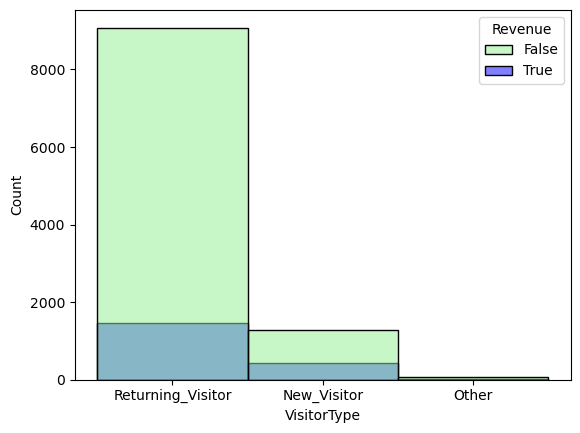

In [6]:
sns.histplot(data=data,x='VisitorType', hue='Revenue', palette=['lightgreen', 'blue'])

In [97]:
visitor_df = data.groupby(['VisitorType', 'Revenue']).count()['Month'].to_frame()
visitor_df['Count'] = visitor_df['Month']
visitor_df = visitor_df.drop(columns=['Month'])

In [98]:
sales = visitor_df.xs(True, level='Revenue')['Count']
total_visits = visitor_df.groupby('VisitorType')['Count'].transform('sum')

In [99]:
# Calculate conversion
conversion = sales / total_visits

# Create a new column in the grouped dataframe
visitor_df['conversion'] = list(conversion)
visitor_df

Count  conversion
VisitorType       Revenue                   
New_Visitor       False     1272    0.249115
                  True       422    0.249115
Other             False       69    0.188235
                  True        16    0.188235
Returning_Visitor False     9081    0.139323
                  True      1470    0.139323

In [106]:
monthly_sales_by_visitor = data.groupby(['VisitorType', 'Month', 'Month_num']).\
                                count()['Revenue'].to_frame().reset_index()
monthly_sales_by_visitor = monthly_sales_by_visitor.sort_values(by='Month_num').\
                                                       drop(columns=['Month_num'])
monthly_sales_by_visitor

,VisitorType,Month,Revenue
2,New_Visitor,Feb,1
13,Returning_Visitor,Feb,183
4,New_Visitor,Mar,232
15,Returning_Visitor,Mar,1675
16,Returning_Visitor,May,3045
5,New_Visitor,May,319
3,New_Visitor,Jul,54
14,Returning_Visitor,Jul,378
0,New_Visitor,Aug,72
11,Returning_Visitor,Aug,361


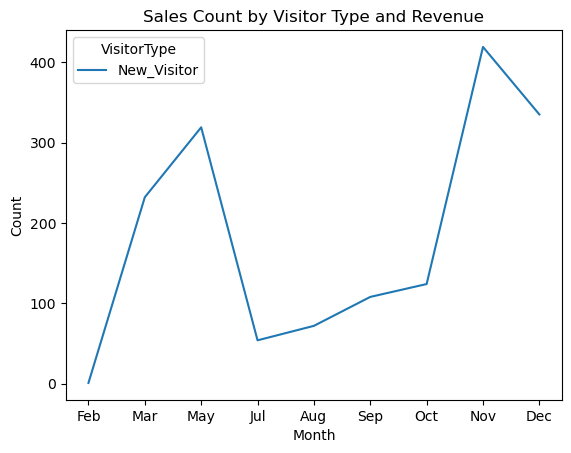

In [107]:
sns.lineplot(data=monthly_sales_by_visitor[monthly_sales_by_visitor['VisitorType'] == 'New_Visitor'],
             x='Month', y='Revenue', hue='VisitorType')

# Display the plot
plt.title('Sales Count by Visitor Type and Revenue')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

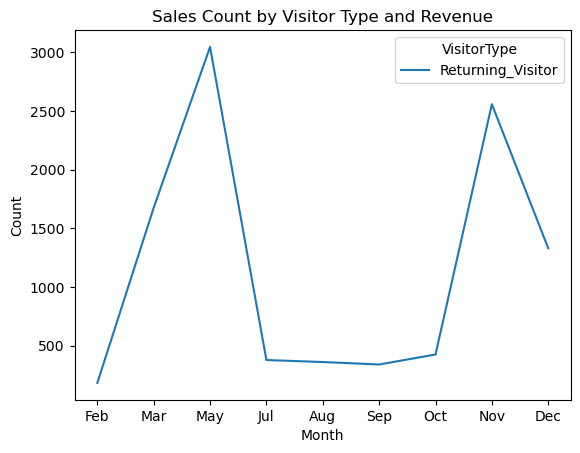

In [108]:
sns.lineplot(data=monthly_sales_by_visitor[monthly_sales_by_visitor['VisitorType'] == 'Returning_Visitor'],
             x='Month', y='Revenue', hue='VisitorType')

# Display the plot
plt.title('Sales Count by Visitor Type and Revenue')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

**Main Insights**

- The conversion rate for returning customers is much lower than new customers, 25% and 14% respectively. Sales peak for returning customers in November; whereas sales peak for new customers in May.
- After dummy variables were created, 13 variables were removed.
- The final data contains 5 variables, Revenue as the target and PageValues, Administrative_Duration, ProductRelated_Duration, and BounceRates.

## Data Pre-processing Pipeline

Based on the analysis above, the following data cleaning and pre-processing steps will be taken:
- Categorical variables will be converted to dummy variables
- Data will be output as parquet file

In [24]:
def cleaning_pipeline(dataframe, output_path):
    """ Takes a dataframe representing the data that needs to be pre-processed and
            an output path that represents the location where the file will be saved.
    """
    return dataframe.to_parquet(output_path)

In [25]:
output = "../data/cleaned_data.parquet"
cleaning_pipeline(data, output)